In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('./data/credit_risk_data.csv')
data = data.drop(['ID'], axis=1)
data.columns = ['Age', 'Marriage', 'Estate_Owned', 'Income', 'Credit_Risk']
data.head()

,Age,Marriage,Estate_Owned,Income,Credit_Risk
0,25,Độc thân,Ở cùng bố mẹ,7000000,0
1,40,Đã kết hôn,Nhà sở hữu,18000000,0
2,35,Từng ly hôn,Nhà thuê,12000000,1
3,27,Đã kết hôn,Ở cùng bố mẹ,9000000,1
4,31,Độc thân,Nhà thuê,6000000,1


In [3]:
class ID3:
  def __init__(self) -> None:
    pass

  def entropy(self, feature, target_col):
    elements, count = np.unique(target_col, return_counts = True)
    entropy = np.sum(
        [(-count[i]/np.sum(count))*np.log2(count[i]/np.sum(count))
        for i in range(len(elements))])
    print(f"feature: {feature}, entropy: {entropy}")
    return entropy

  def information_gain(self, data, feature, target):
    total_entropy = self.entropy(feature, data[target])
    values, counts = np.unique(data[feature], return_counts=True)

    weighted_entropy = np.sum([
        (counts[i] / np.sum(counts)) *
        self.entropy(data[data[feature] == values[i]] ,data[data[feature] == values[i]][target])
        for i in range(len(values))
    ])
    print(f"feature: {feature}, total entropy: {total_entropy}, weighted entropy: {weighted_entropy}")
    print(f"Information feature: {feature}, information gain: {total_entropy - weighted_entropy}")
    return total_entropy - weighted_entropy

  def id3(self, data, original_data, features, target, parent_node_class=None):
    # base case 1: if all class in the set are the same
    if len(np.unique(data[target])) == 1:
      print(f"returning with pure data")
      return np.unique(data[target])[0]

    # base case 2: if subset is empty -> return most frequent class in original dataset
    if len(data) == 0:
      print("returning with empty set")
      return np.unique(original_data[target])[
          np.argmax(np.unique(original_data[target], return_counts=True)[1])
      ]
    # base case 3: if feature set is empty -> return parent node class
    if len(features) == 0:
      print("returning with empty feature set")
      return parent_node_class

    # get most frequent class for fallback
    parent_node_class = np.unique(data[target])[np.argmax(np.unique(data[target], return_counts=True)[1])]
    gains = [self.information_gain(data, feature, target) for feature in features]
    best_feature = features[np.argmax(gains)]
    print(f"Best feature: {best_feature}")

    # initialize tree, create subset
    tree = {best_feature: {}}
    remaining_features = [f for f in features if f != best_feature]

    # build tree for each value in the best feature
    for value in np.unique(data[best_feature]):
      print(f"selected value: {value}")
      subset = data[data[best_feature] == value]
      subtree = self.id3(subset, original_data, remaining_features, target, parent_node_class)
      tree[best_feature][value] = subtree

    return tree

In [4]:
# binning data
data_binned = data.copy()
# Binning Age: [25, 33], (33, 41], (41, 49]
data_binned['Age'] = pd.cut(data['Age'], bins=[24, 32, 41, 49], labels=['25-33', '33-41', '41-49'])
# Binning Income: [5m, 10m], (10m, 15m], (15m, 20m]
data_binned['Income'] = pd.cut(data['Income'], bins=[4999999, 10000000, 15000000, 20000000], labels=['5m-10m', '10m-15m', '15m-20m'])

features = list(data_binned.columns[:-1])
model = ID3()
tree = model.id3(data_binned, data_binned, features, 'Credit_Risk')

print("\nDecision Tree:")
import pprint
pprint.pprint(tree)

feature: Age, entropy: 0.9709505944546686
feature:       Age    Marriage  Estate_Owned  Income  Credit_Risk
0   25-33    Độc thân  Ở cùng bố mẹ  5m-10m            0
3   25-33  Đã kết hôn  Ở cùng bố mẹ  5m-10m            1
4   25-33    Độc thân      Nhà thuê  5m-10m            1
7   25-33  Đã kết hôn      Nhà thuê  5m-10m            1
9   25-33    Độc thân      Nhà thuê  5m-10m            0
13  25-33    Độc thân      Nhà thuê  5m-10m            1
14  25-33  Đã kết hôn  Ở cùng bố mẹ  5m-10m            1, entropy: 0.863120568566631
feature:       Age     Marriage  Estate_Owned   Income  Credit_Risk
1   33-41   Đã kết hôn    Nhà sở hữu  15m-20m            0
2   33-41  Từng ly hôn      Nhà thuê  10m-15m            1
5   33-41   Đã kết hôn    Nhà sở hữu   5m-10m            1
8   33-41  Từng ly hôn  Ở cùng bố mẹ   5m-10m            1
10  33-41   Đã kết hôn    Nhà sở hữu  10m-15m            0, entropy: 0.9709505944546686
feature:       Age    Marriage Estate_Owned   Income  Credit_Risk
6   41-

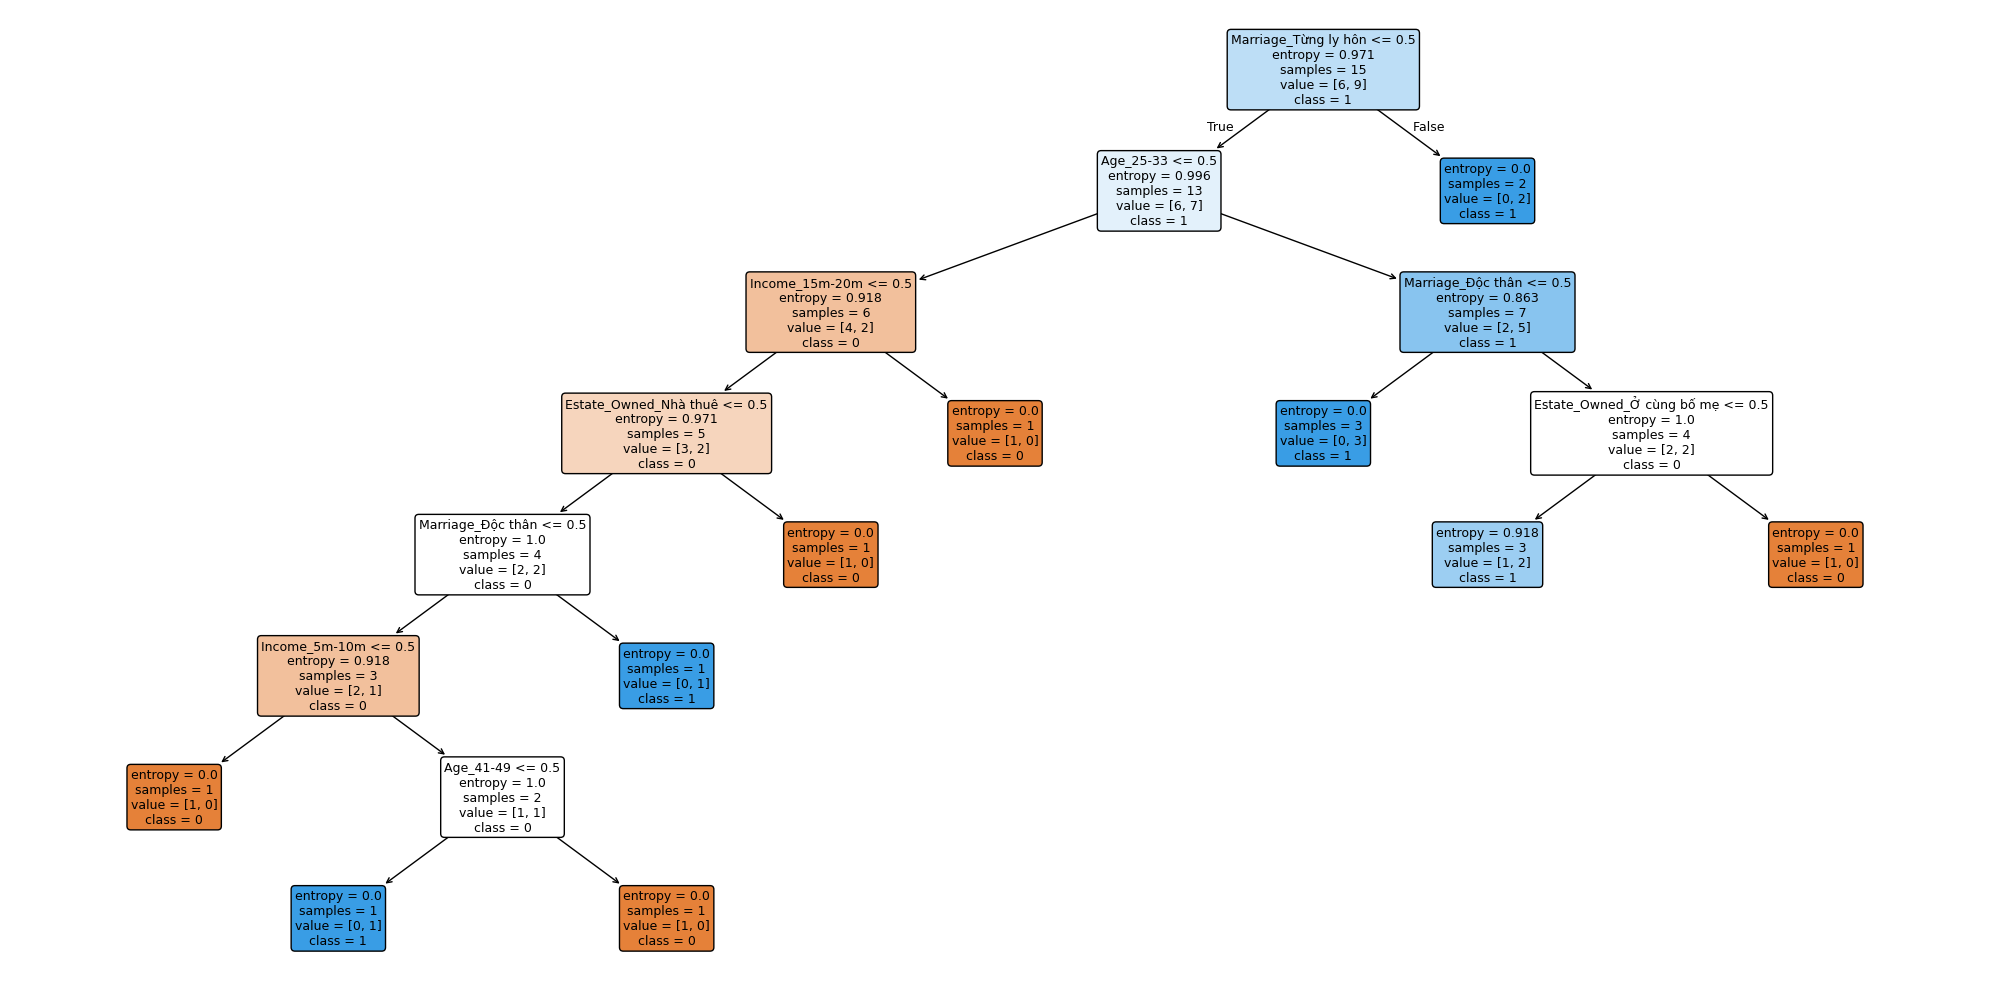

In [5]:
# sklearn implementation

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = data_binned.drop(columns='Credit_Risk')
y = data_binned['Credit_Risk']

# one hot encoding
categorical_features = X.select_dtypes(include=['object', 'category']).columns
preprocessor = ColumnTransformer(
    transformers=[('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough',
    verbose_feature_names_out=False
)
X_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_encoded, y)

# Visualize the fitted decision tree.
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=[str(label) for label in clf.classes_],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.tight_layout()
plt.show()
